# Hall of Fame — exploring HallOfFame.csv

## Exploration 1: What does the Hall of Fame data actually look like?

In [161]:
import pandas as pd

hof = pd.read_csv("core/HallOfFame.csv")
hof.head()

,playerID,yearid,votedBy,ballots,needed,votes,inducted,category,needed_note
0,cobbty01,1936,BBWAA,226.0,170.0,222.0,Y,Player,NaN
1,ruthba01,1936,BBWAA,226.0,170.0,215.0,Y,Player,NaN
2,wagneho01,1936,BBWAA,226.0,170.0,215.0,Y,Player,NaN
3,mathech01,1936,BBWAA,226.0,170.0,205.0,Y,Player,NaN
4,johnswa01,1936,BBWAA,226.0,170.0,189.0,Y,Player,NaN


In [176]:
hof.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4191 entries, 0 to 4190
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   playerID     4191 non-null   object 
 1   yearid       4191 non-null   int64  
 2   votedBy      4191 non-null   object 
 3   ballots      3994 non-null   float64
 4   needed       3837 non-null   float64
 5   votes        3994 non-null   float64
 6   inducted     4191 non-null   object 
 7   category     4191 non-null   object 
 8   needed_note  157 non-null    object 
dtypes: float64(3), int64(1), object(5)
memory usage: 294.8+ KB


Each row is one player's ballot in one election year, not a membership list — `cobbty01`, `ruthba01` and friends show up here because they were voted on in 1936, and the `inducted` column is what actually separates the Hall of Famers from everyone else who was considered.

## Exploration 2: Who actually does the voting? A look at the `votedBy` column.

In [162]:
import matplotlib.pyplot as plt

voted_by = hof["votedBy"].value_counts()
voted_by

votedBy
BBWAA               3756
Veterans             193
Run Off               81
Nominating Vote       76
Old Timers            30
Negro League          26
Final Ballot          21
Centennial             6
Special Election       2
Name: count, dtype: int64

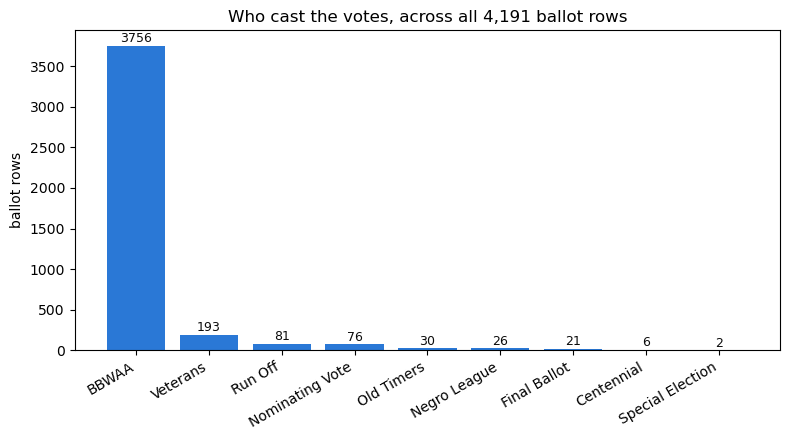

In [163]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(voted_by.index, voted_by.values, color="#2a78d6")

for x, v in voted_by.items():
    ax.text(x, v + 40, f"{v}", ha="center", fontsize=9, color="#0b0b0b")

ax.set_ylabel("ballot rows")
ax.set_title("Who cast the votes, across all 4,191 ballot rows")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

BBWAA (the baseball writers) accounts for 3,756 of the 4,191 rows — almost 90% — completely dwarfing Veterans (193), Run Off (81), Nominating Vote (76), and the small Negro Leagues/Centennial/Special Election committees, which barely register on this scale.

## Exploration 3: Of every ballot ever cast, how many resulted in induction?

In [164]:
hof["inducted"].value_counts()

inducted
N    3868
Y     323
Name: count, dtype: int64

Only 323 of the 4,191 ballot rows say "Y" — the other 3,868 are rejections. So most of this table is a record of players who were nominated and turned down, sometimes year after year.

## Exploration 4: How many distinct people are actually inducted, and can someone get in twice?

In [165]:
inducted = hof[hof["inducted"] == "Y"]
print("inducted rows:", len(inducted))
print("unique playerIDs:", inducted["playerID"].nunique())
inducted["playerID"].duplicated().sum()

inducted rows: 323
unique playerIDs: 323


0

323 rows, 323 unique people, zero duplicates — nobody is ever inducted twice. Makes sense: once you're in the Hall, there's nothing left to vote on.

## Exploration 5: What share of all ballots cast actually lead to induction?

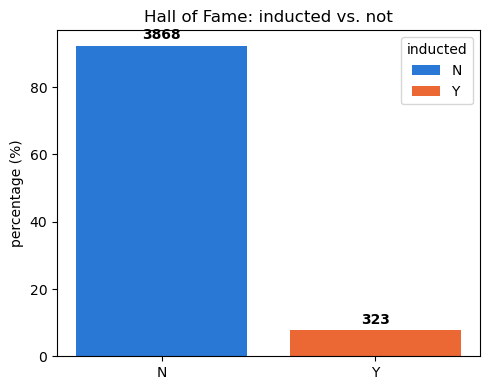

In [166]:
counts = hof["inducted"].value_counts()
pct = counts / counts.sum() * 100
colors = {"N": "#2a78d6", "Y": "#eb6834"}

fig, ax = plt.subplots(figsize=(5, 4))
for label in counts.index:
    ax.bar(label, pct[label], color=colors[label], label=label)
    ax.text(label, pct[label] + 1, f"{counts[label]}", ha="center", va="bottom", fontweight="bold")

ax.set_ylabel("percentage (%)")
ax.set_title("Hall of Fame: inducted vs. not")
ax.legend(title="inducted")
plt.tight_layout()
plt.show()

Just 7.7% of all ballots end in induction. The vast majority of a player's or manager's candidacy history in this table is "no."

## Exploration 6: Of the people who made it in, how many were Players vs. Managers, Umpires, or Pioneers/Executives?

C:\Users\Drish\AppData\Local\Temp\ipykernel_1668\292221491.py:18: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


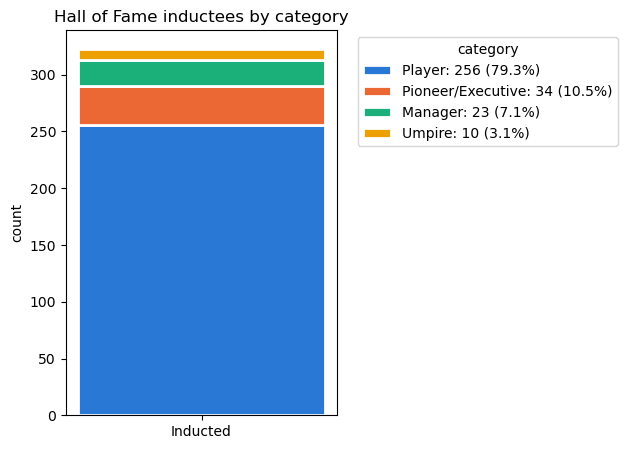

In [167]:
inducted = hof[hof["inducted"] == "Y"]
cat_counts = inducted["category"].value_counts()
cat_pct = cat_counts / cat_counts.sum() * 100

colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]  # categorical slots 1-4

fig, ax = plt.subplots(figsize=(3.5, 5))
bottom = 0
for color, label in zip(colors, cat_counts.index):
    count = cat_counts[label]
    ax.bar("Inducted", count, bottom=bottom, color=color, edgecolor="white", linewidth=2,
           label=f"{label}: {count} ({cat_pct[label]:.1f}%)")
    bottom += count

ax.set_ylabel("count")
ax.set_title("Hall of Fame inductees by category")
ax.legend(title="category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Players dominate at 79.3% of all inductees, with Pioneers/Executives, Managers, and Umpires splitting the rest fairly evenly. That's expected — the Hall exists primarily to honor on-field careers.

## Exploration 7: How selective is induction, relative to everyone who was ever eligible?

In [168]:
appearances = pd.read_csv("core/Appearances.csv")
managers = pd.read_csv("core/Managers.csv")

pool_sizes = {
    "Player": appearances["playerID"].nunique(),
    "Manager": managers["playerID"].nunique(),
}

for role, pool in pool_sizes.items():
    ind = cat_counts.get(role, 0)
    print(f"{role}: {ind} inducted out of {pool} ever -> {ind / pool * 100:.2f}%")

print("Pioneer/Executive and Umpire: no roster table in this dataset, so no pool size available")

Player: 256 inducted out of 19182 ever -> 1.33%
Manager: 23 inducted out of 701 ever -> 3.28%
Pioneer/Executive and Umpire: no roster table in this dataset, so no pool size available


Only about 1.3% of everyone who ever played and 3.3% of everyone who ever managed made the Hall — managing is the slightly less crowded path. Umpires and Pioneers/Executives can't be rated this way since Lahman never tracked a full roster for those roles.

## Exploration 8: Of the people who eventually got in, who took the longest — appearing on the ballot the most times before finally making it?

In [169]:
ppl = pd.read_csv("core/People.csv")
name = (ppl.set_index("playerID")["nameFirst"].fillna("") + " " + ppl.set_index("playerID")["nameLast"].fillna(""))

ballots = hof.groupby("playerID").size()
ever_inducted = hof.groupby("playerID")["inducted"].apply(lambda s: (s == "Y").any())

inducted_ids = ever_inducted[ever_inducted].index
longest_road = ballots.reindex(inducted_ids).sort_values(ascending=False).head(15)
pd.DataFrame({"player": name.reindex(longest_road.index), "times_on_ballot": longest_road.values})

,player,times_on_ballot
playerID,,
roushed01,Edd Roush,20
youngro01,Ross Youngs,19
schalra01,Ray Schalk,18
ruffire01,Red Ruffing,18
wheatza01,Zack Wheat,17
rizzuph01,Phil Rizzuto,17
wilsoha01,Hack Wilson,17
rixeyep01,Eppa Rixey,17
faberre01,Red Faber,17


Edd Roush took 20 tries. Let's see what that actually looked like year by year.

In [170]:
roush = hof[hof["playerID"] == "roushed01"].sort_values("yearid")
print("distinct years:", roush["yearid"].nunique(), " total rows:", len(roush))
roush[["yearid", "votedBy", "category", "ballots", "needed", "votes", "inducted"]]

distinct years: 20  total rows: 20


,yearid,votedBy,category,ballots,needed,votes,inducted
70,1936,BBWAA,Player,226.0,170.0,2.0,N
144,1937,BBWAA,Player,201.0,151.0,10.0,N
265,1938,BBWAA,Player,262.0,197.0,9.0,N
387,1939,BBWAA,Player,274.0,206.0,8.0,N
528,1942,BBWAA,Player,233.0,175.0,1.0,N
578,1945,BBWAA,Player,247.0,186.0,5.0,N
695,1946,Nominating Vote,Player,202.0,NaN,11.0,N
769,1947,BBWAA,Player,161.0,121.0,25.0,N
807,1948,BBWAA,Player,121.0,91.0,17.0,N
933,1949,BBWAA,Player,153.0,115.0,14.0,N


All 20 rows are distinct years (1936-1960 on BBWAA/Nominating Vote ballots), and he only got in during 1962 through the Veterans Committee — after the writers had given up on him entirely for two years.

## Exploration 9: Who was on the ballot the most times but NEVER got inducted?

In [171]:
ballots = hof.groupby("playerID").size()
ever_inducted = hof.groupby("playerID")["inducted"].apply(lambda s: (s == "Y").any())

never_inducted = ballots[~ever_inducted].sort_values(ascending=False).head(15)
pd.DataFrame({"player": name.reindex(never_inducted.index), "times_on_ballot": never_inducted.values})

,player,times_on_ballot
playerID,,
gowdyha01,Hank Gowdy,17
vernomi01,Mickey Vernon,16
newcodo01,Don Newcombe,16
darkal01,Al Dark,16
marisro01,Roger Maris,15
kluszte01,Ted Kluszewski,15
murphda05,Dale Murphy,15
thomsbo01,Bobby Thomson,15
tiantlu01,Luis Tiant,15


Hank Gowdy leads with 17 appearances and never got in. Worth looking at how close he actually came each time.

## Exploration 10: How close did Hank Gowdy actually get, across his whole candidacy?

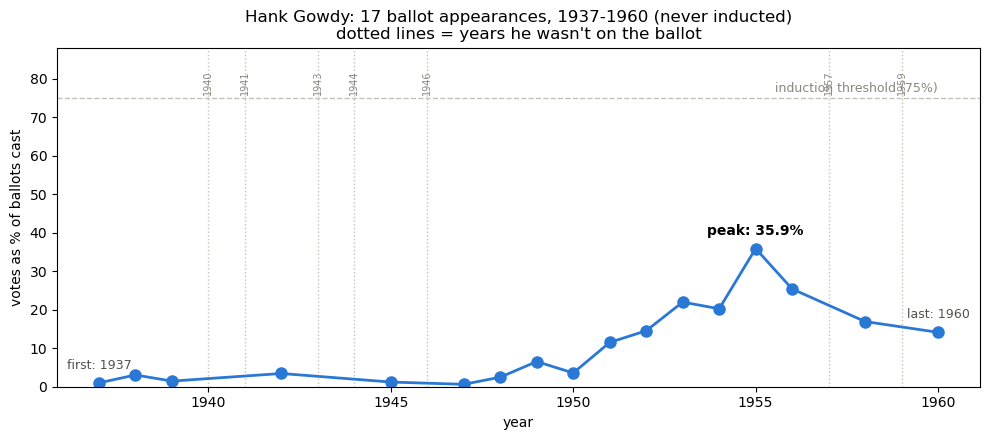

In [172]:
gowdy = hof[hof["playerID"] == "gowdyha01"].sort_values("yearid")
gowdy_pct = gowdy["votes"] / gowdy["ballots"] * 100   # his actual share of all votes cast
start_year, end_year = gowdy["yearid"].min(), gowdy["yearid"].max()

fig, ax = plt.subplots(figsize=(10, 4.5))

# reference line: 75% of ballots = induction threshold
ax.axhline(75, color="#c3c2b7", linewidth=1, linestyle="--")
ax.text(end_year, 76.5, "induction threshold (75%)", ha="right", color="#898781", fontsize=9)

ax.plot(gowdy["yearid"], gowdy_pct, color="#2a78d6", linewidth=2, marker="o", markersize=8)

# years he WASN'T on the ballot: dotted line + the year labeled at the top
all_years = range(start_year, end_year + 1)
missing_years = sorted(set(all_years) - set(gowdy["yearid"]))
for y in missing_years:
    ax.axvline(y, color="#c3c2b7", linewidth=1, linestyle=":", zorder=0)
    ax.text(y, 82, str(y), rotation=90, ha="center", va="top", fontsize=7, color="#898781")

# label the first year and last year he appeared on the ballot
for year, label in [(start_year, f"first: {start_year}"), (end_year, f"last: {end_year}")]:
    row = gowdy[gowdy["yearid"] == year].iloc[0]
    pct = row["votes"] / row["ballots"] * 100
    ax.annotate(label, (year, pct), textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=9, color="#52514e")

# label the peak
peak_year = gowdy.loc[gowdy_pct.idxmax(), "yearid"]
ax.annotate(f"peak: {gowdy_pct.max():.1f}%", (peak_year, gowdy_pct.max()),
            textcoords="offset points", xytext=(0, 10), ha="center", fontweight="600")

ax.set_ylim(0, 88)
ax.set_xlabel("year")
ax.set_ylabel("votes as % of ballots cast")
ax.set_title(f"Hank Gowdy: 17 ballot appearances, {start_year}-{end_year} (never inducted)\n"
             "dotted lines = years he wasn't on the ballot")
plt.tight_layout()
plt.show()

He peaked at just 35.9% of the vote in 1955 — nowhere near the 75% he needed — and drifted in and out of the ballot for over two decades. He was never a real threat to get in; he was just a name the writers kept including.

## Exploration 11: Restricting to genuine BBWAA competitive elections, how many tries does it typically take to get in?

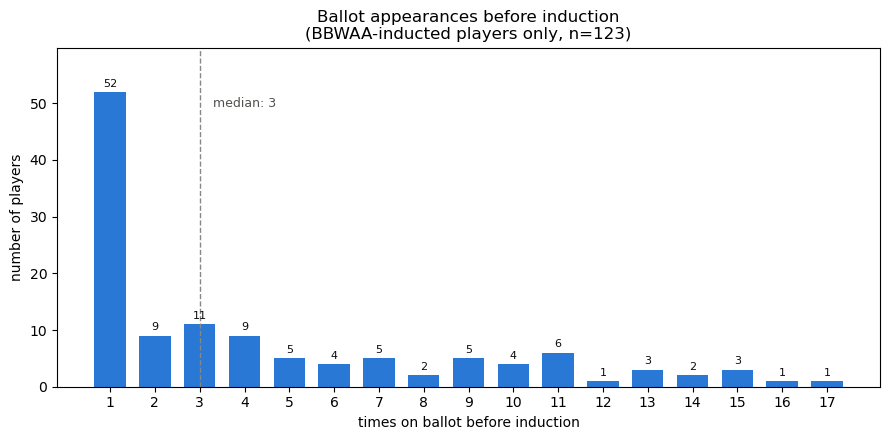

In [173]:
bbwaa_inducted = hof[(hof["inducted"] == "Y") & (hof["votedBy"] == "BBWAA")]["playerID"]
appearances_bbwaa = hof[hof["playerID"].isin(bbwaa_inducted)].groupby("playerID").size()

dist = appearances_bbwaa.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(dist.index, dist.values, color="#2a78d6", width=0.7)

median = appearances_bbwaa.median()
ax.axvline(median, color="#898781", linestyle="--", linewidth=1)
ax.text(median + 0.3, dist.max() * 0.95, f"median: {median:.0f}", color="#52514e", fontsize=9)

for x, v in dist.items():
    ax.text(x, v + 0.6, f"{v}", ha="center", va="bottom", fontsize=8, color="#0b0b0b")

ax.set_ylim(0, dist.max() * 1.15)
ax.set_xticks(dist.index)
ax.set_xlabel("times on ballot before induction")
ax.set_ylabel("number of players")
ax.set_title(f"Ballot appearances before induction\n(BBWAA-inducted players only, n={len(appearances_bbwaa)})")
plt.tight_layout()
plt.show()

First-ballot induction is actually the single most common outcome — 52 of 123 BBWAA electees (42%) got in immediately. But it's a long tail after that: the median is 3 tries, and a handful of players (Red Ruffing, Pee Wee Reese, Zack Wheat) needed 15-17.

## Exploration 12: Of the players who came closest without ever getting in, do any have salary data in this dataset — and how did the best-covered one's pay compare to the league?

In [174]:
sal = pd.read_csv("core/Salaries.csv")

candidates = never_inducted.index  # the 15 most-nominated-but-never-inducted players
info = ppl.set_index("playerID").loc[candidates, ["debut", "finalGame"]].copy()
info["player"] = name.reindex(candidates)
info["salary_rows"] = sal.groupby("playerID").size().reindex(candidates).fillna(0).astype(int)
info.sort_values("salary_rows", ascending=False)

,debut,finalGame,player,salary_rows
playerID,,,,
mattido01,1982-09-08,1995-10-01,Don Mattingly,11
murphda05,1976-09-13,1993-05-21,Dale Murphy,9
johnto01,1963-09-06,1989-05-25,Tommy John,5
garvest01,1969-09-01,1987-05-23,Steve Garvey,3
gowdyha01,1910-09-13,1930-08-29,Hank Gowdy,0
vernomi01,1939-07-08,1960-09-27,Mickey Vernon,0
newcodo01,1949-05-20,1960-10-01,Don Newcombe,0
darkal01,1946-07-14,1960-10-02,Al Dark,0
marisro01,1957-04-16,1968-09-29,Roger Maris,0


Salaries.csv only covers 1985-2016, so anyone who retired earlier (Hank Gowdy included) has zero rows. Don Mattingly is the best-covered case — 11 seasons, almost his entire career.

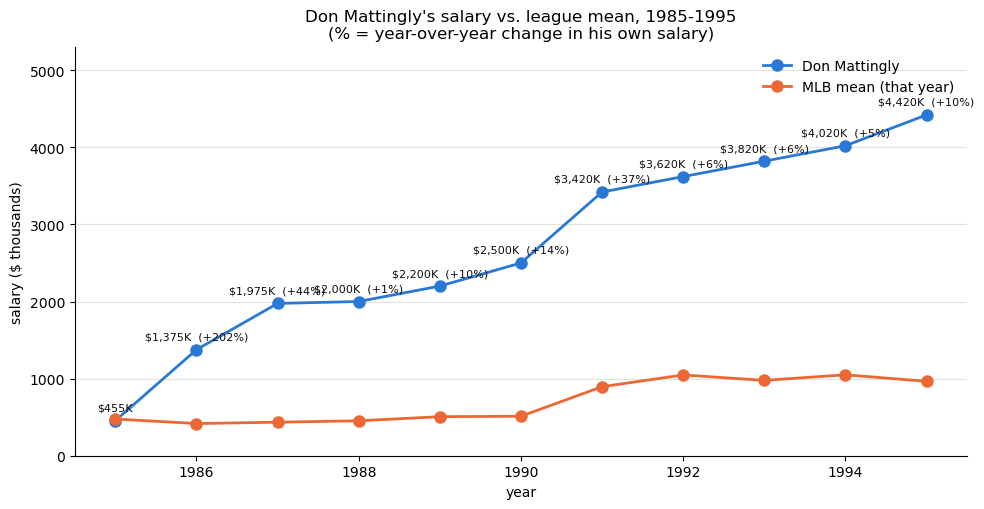

In [175]:
matt = sal[sal["playerID"] == "mattido01"].sort_values("yearID").reset_index(drop=True)
matt["pct_change"] = matt["salary"].pct_change() * 100
mean_by_year = sal.groupby("yearID")["salary"].mean().reindex(matt["yearID"]).values

fig, ax = plt.subplots(figsize=(10, 5.2))
ax.plot(matt["yearID"], matt["salary"] / 1000, color="#2a78d6", linewidth=2, marker="o", markersize=8, label="Don Mattingly")
ax.plot(matt["yearID"], mean_by_year / 1000, color="#eb6834", linewidth=2, marker="o", markersize=8, label="MLB mean (that year)")

for _, row in matt.iterrows():
    x, y = row["yearID"], row["salary"] / 1000
    label = f"${y:,.0f}K"
    if pd.notna(row["pct_change"]):
        label += f"  ({row['pct_change']:+.0f}%)"
    ax.text(x, y + 130, label, ha="center", fontsize=8, color="#0b0b0b")

ax.set_xlabel("year")
ax.set_ylabel("salary ($ thousands)")
ax.set_title("Don Mattingly's salary vs. league mean, 1985-1995\n(% = year-over-year change in his own salary)")
ax.legend(frameon=False)
ax.set_ylim(0, matt["salary"].max() / 1000 * 1.2)
ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

His salary rocketed from $455K to $4.42M over 11 seasons (a 202% jump alone in his second year), while the league mean barely moved off six figures for most of that stretch — by 1995 he was earning roughly 4-5x the average player, well before free agency and superstar contracts became the norm they are today.